1/1 [==============================] - 3s 3s/step

🧠 Predicted Label: Light Diseases and Disorders of Pigmentation
✅ Confidence: 27.60%


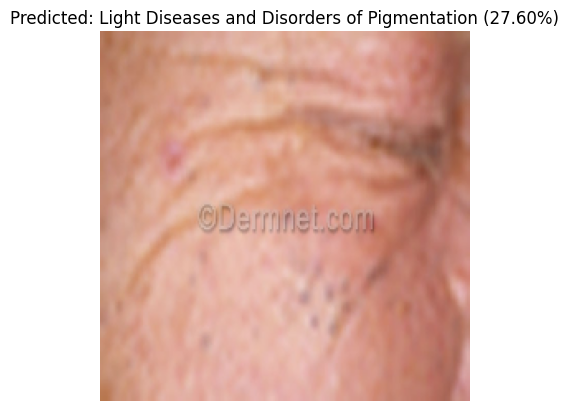

In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet import preprocess_input

# Load the model
model = load_model('vitamindeficiency.h5')

# Load class labels
with open("class_indices.json", "r") as f:
    class_indices = json.load(f)
index_to_class = {v: k for k, v in class_indices.items()}

# Image input size for ResNet
img_height, img_width = 224, 224

# Function to preprocess image
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)  # Use ResNet-specific preprocessing
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# Function to predict and display results
def predict_image(img_path, true_label=None):
    img_array = preprocess_image(img_path)
    predictions = model.predict(img_array)
    predicted_index = np.argmax(predictions)
    predicted_label = index_to_class[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    print(f"\n🧠 Predicted Label: {predicted_label}")
    print(f"✅ Confidence: {confidence:.2f}%")

    # Show image with prediction
    img = image.load_img(img_path, target_size=(img_height, img_width))
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_label} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    # Optional Top-1 Accuracy
    if true_label:
        correct = (predicted_label == true_label)
        print(f"Top-1 Accuracy: {'✅ Correct' if correct else '❌ Incorrect'}")

# 🔍 Example usage
predict_image('1.jpg')  # Change to your image path and label
